# Real Pipeline (Leakage-Safe) → HAR Baseline → Backtest

Running the full pipeline end-to-end using the *real* dataset. The idea is simple: load leakage-safe features, respect the fixed splits, fit HAR variants, and then see how a cost-aware backtest behaves. Along the way we export every artifact so the CLI and notebooks stay in sync.

### Environment wiring
Before touching any data I like to get the boring pieces nailed down: import the scientific stack, pick plotting defaults, and figure out where this notebook is actually running from. The cell below sniffs whether the kernel launched inside `notebooks/`, hops up to the repo root if needed, and then builds all of the path helpers so later steps don’t accidentally spray files in the wrong place.

In [3]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

plt.rcParams["figure.figsize"] = (10, 3)
pd.options.display.float_format = "{:,.6f}".format

# Resolve project root even when the notebook kernel starts inside notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# Paths (tweak if your folders differ)
DATA_DIR = ROOT / "data"
PROC = DATA_DIR / "processed"
RAW  = DATA_DIR / "raw"
CONF = ROOT / "configs"
EXP  = ROOT / "experiments"
PRED_DIR = EXP / "preds"
RES_DIR  = EXP / "results"
SPLIT_DIR= EXP / "splits"

for p in [PROC, RAW, CONF, PRED_DIR, RES_DIR, SPLIT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Detect TFT-ready artifacts first, then fall back to builder parquet
TFT_READY_CANDIDATES = {
    "train": DATA_DIR / "tft_ready_train.csv",
    "val": DATA_DIR / "tft_ready_val.csv",
    "test": DATA_DIR / "tft_ready_test.csv",
    "dataset": DATA_DIR / "tft_ready_dataset.csv",
}
USE_TFT_READY = any(path.exists() for path in TFT_READY_CANDIDATES.values()) or (PROC / "tft_ready_small.parquet").exists()
USE_BUILDER_PARQUET = (PROC / "features.parquet").exists()

print("Notebook root:", Path.cwd().resolve())
print("Using project root:", ROOT)
print("Use TFT-ready? ", USE_TFT_READY)
print("Use builder parquet? ", USE_BUILDER_PARQUET)

Notebook root: /Users/sonalilonkar/Desktop/Projects/DL_Project/vol-forecasting/notebooks
Using project root: /Users/sonalilonkar/Desktop/Projects/DL_Project/vol-forecasting
Use TFT-ready?  True
Use builder parquet?  True


### Load TFT-ready or builder features
This block is my gatekeeper for clean inputs. I try the TFT-ready CSVs first so we inherit the same leakage-safe targets used elsewhere; if they’re missing I gracefully fall back to the builder’s parquet artifact. No matter which path hits, the code standardizes the column names and sorts `(ticker, date)` so every downstream consumer sees a consistent panel.

In [4]:
def load_tft_ready():
    split_files = {k: v for k, v in TFT_READY_CANDIDATES.items() if k in ("train","val","test") and v.exists()}
    if split_files:
        frames = []
        for split_name, path in split_files.items():
            part = pd.read_csv(path, low_memory=False)
            part["split_hint"] = split_name
            frames.append(part)
        df = pd.concat(frames, ignore_index=True)
        print(f"Loaded {len(frames)} split files from data/tft_ready_*.csv")
    elif (PROC / "tft_ready_small.parquet").exists():
        df = pd.read_parquet(PROC / "tft_ready_small.parquet")
        print("Loaded PROC/tft_ready_small.parquet")
    elif TFT_READY_CANDIDATES["dataset"].exists():
        df = pd.read_csv(TFT_READY_CANDIDATES["dataset"], low_memory=False)
        print("Loaded data/tft_ready_dataset.csv")
    else:
        raise FileNotFoundError("No TFT-ready file found. Place tft_ready_{train,val,test}.csv or tft_ready_dataset.csv under data/")
    # Normalize key column names to a common contract
    if "asset" in df.columns and "ticker" not in df.columns:
        df = df.rename(columns={"asset": "ticker"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker","date"]).drop_duplicates(["ticker","date"]).reset_index(drop=True)
    return df

def load_builder_parquet():
    df = pd.read_parquet(PROC / "features.parquet")
    # Builder uses 'asset' and has 'log_rv' + logrv_ma_* windows; normalize names
    if "asset" in df.columns:
        df = df.rename(columns={"asset": "ticker"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker","date"]).drop_duplicates(["ticker","date"]).reset_index(drop=True)
    return df

if USE_TFT_READY:
    df = load_tft_ready()
elif USE_BUILDER_PARQUET:
    df = load_builder_parquet()
else:
    raise RuntimeError("Neither TFT-ready dataset nor features.parquet found. Run your feature builder first.")

print(df.shape, df["date"].min(), df["date"].max(), "#tickers:", df["ticker"].nunique())
df.head()

Loaded 3 split files from data/tft_ready_*.csv
(13964, 44) 2011-01-11 00:00:00 2024-12-23 00:00:00 #tickers: 4


,date,ticker,logvol_t,target_logvol_t+1,target_logvol_t+5,target_logvol_t+22,weekday,is_month_end,is_opex,is_holiday_eve,...,roll_mean_vol_132d,roll_std_vol_132d,roll_mean_ret_252d,roll_std_ret_252d,roll_mean_vol_252d,roll_std_vol_252d,pca_vol_cs_1,pca_vol_cs_2,pca_vol_cs_3,split_hint
0,2011-01-11,GLD,-5.070120,-5.174413,-4.311878,-3.344378,1,0,0,0,...,0.006232,0.002946,0.000685,0.010444,0.006980,0.003172,-0.189073,0.922351,-0.811921,train
1,2011-01-12,GLD,-5.174413,-4.853728,-4.330529,-3.352055,2,0,0,0,...,0.006234,0.002946,0.000792,0.010357,0.006945,0.003130,2.027990,1.011525,0.279239,train
2,2011-01-13,GLD,-4.853728,-4.963198,-4.457583,-3.374136,3,0,0,0,...,0.006241,0.002943,0.000771,0.010345,0.006919,0.003113,0.666903,-0.005867,2.288776,train
3,2011-01-14,GLD,-4.963198,-5.450606,-4.434396,-3.371583,4,0,0,1,...,0.006241,0.002943,0.000712,0.010367,0.006911,0.003109,2.124020,0.849803,0.386406,train
4,2011-01-18,GLD,-5.450606,-5.419435,-4.368734,-3.374667,1,0,0,0,...,0.006262,0.002938,0.000713,0.010365,0.006900,0.003103,2.066790,0.059928,-0.236948,train


### Leakage smoke test
Once the data is loaded I sanity-check that it behaves like a forward-looking feature table. This helper looks for obvious current-level columns, inspects the target-versus-current correlation, and confirms the lagged windows actually exist. If any of those checks fail, I’d rather stop immediately than debug mysterious HAR regressions later.

In [5]:
def leakage_smoke(df: pd.DataFrame):
    # Should have some notion of "current log vol" and future targets if TFT-ready
    candidates_now = [c for c in df.columns if c in ("logvol_t","log_rv","logrv_t","y_true_logrv")]
    print("Level candidates:", candidates_now)
    # If TFT-ready
    if "target_logvol_t+1" in df.columns and "logvol_t" in df.columns:
        d = df[["target_logvol_t+1","logvol_t"]].dropna()
        c = d.corr().iloc[0,1]
        print("corr(target_logvol_t+1, logvol_t) =", round(c, 3))
        assert abs(c) < 0.99, "Suspiciously high correlation; check that targets are truly future."
    # If builder table (has log_rv and lagged rolling features)
    if "log_rv" in df.columns:
        # Ensure windows were computed on shifted data; early rows will be NaN then reasonable coverage
        lag_cols = [c for c in df.columns if c.startswith("logrv_ma_")] or [c for c in df.columns if c.startswith("logrv_")]
        print("Found lag/rolling columns:", lag_cols[:6], "...")
        assert len(lag_cols) > 0, "No lag/rolling features found."
    print("Leakage smoke test: OK")

leakage_smoke(df)


Level candidates: ['logvol_t']
corr(target_logvol_t+1, logvol_t) = 0.59
Leakage smoke test: OK


### Apply repo split definitions
Here I pull the canonical split dates out of `configs/splits.yaml`, honor the embargo buffer, and label each row as train/val/test. I also persist the index files so every script—CLI or notebook—filters on the exact same `(date, ticker)` combinations. That keeps performance comparisons honest.

In [11]:
with open(CONF / "splits.yaml", "r") as f:
    S = yaml.safe_load(f)

TR_S, TR_E = pd.to_datetime(S["train"][0]), pd.to_datetime(S["train"][1])
VA_S, VA_E = pd.to_datetime(S["val"][0]),   pd.to_datetime(S["val"][1])
TE_S, TE_E = pd.to_datetime(S["test"][0]),  pd.to_datetime(S["test"][1])
EMB = int(S.get("embargo_days", 0))

tr_mask_raw = (df["date"]>=TR_S) & (df["date"]<=TR_E)
tr_end_eff = (df.loc[tr_mask_raw,"date"].max() - pd.Timedelta(days=EMB)) if tr_mask_raw.any() else TR_E

is_train = (df["date"]>=TR_S) & (df["date"]<=tr_end_eff)
is_val   = (df["date"]>=VA_S) & (df["date"]<=VA_E)
is_test  = (df["date"]>=TE_S) & (df["date"]<=TE_E)

print("rows train/val/test:", is_train.sum(), is_val.sum(), is_test.sum())

# Persist (date,ticker) indices so every script uses identical rows
df.loc[is_train, ["date","ticker"]].to_csv(SPLIT_DIR/"train_index.csv", index=False)
df.loc[is_val,   ["date","ticker"]].to_csv(SPLIT_DIR/"val_index.csv",   index=False)
df.loc[is_test,  ["date","ticker"]].to_csv(SPLIT_DIR/"test_index.csv",  index=False)
sorted([p.name for p in SPLIT_DIR.glob("*.csv")])

rows train/val/test: 6984 1972 4992


['test_index.csv', 'train_index.csv', 'val_index.csv']

### Visual sanity check
Numbers are nice, but a quick chart usually catches silly mistakes faster. I grab the longest-lived ticker, plot its log-vol history, and paint the train/val/test spans (plus any embargo gap) so I can visually confirm the splits line up with what’s in the config file.

/var/folders/6g/b8fqkdb93753h_gq88s28bf00000gn/T/ipykernel_76665/1058794851.py:19: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(bylabel.values(), bylabel.keys(), ncol=4, fontsize=8)


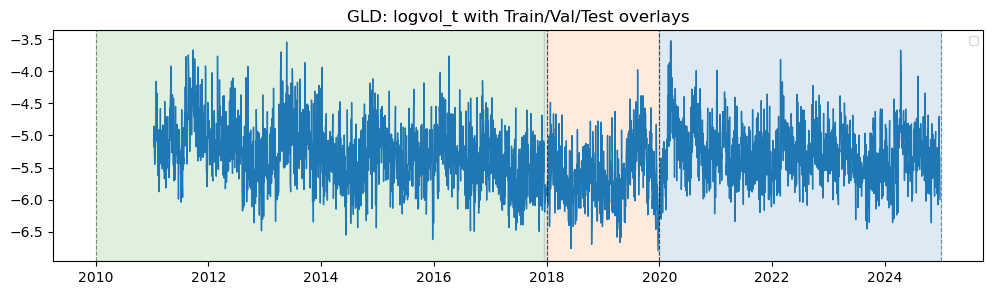

In [12]:
def shade(ax, s, e, color, label): 
    if pd.isna(s) or pd.isna(e): return
    ax.axvspan(s, e, color=color, alpha=0.15, label=label)

# Pick one ticker with long history
ex = df["ticker"].value_counts().idxmax()
g = df[df["ticker"]==ex].sort_values("date").copy()

ycol = ("logvol_t" if "logvol_t" in g.columns else "log_rv")
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(g["date"], g[ycol], lw=1)
shade(ax, TR_S, tr_end_eff, "tab:green", "Train (usable)")
if EMB>0: shade(ax, tr_end_eff, TR_E, "gray", f"Embargo {EMB}d")
shade(ax, VA_S, VA_E, "tab:orange", "Val")
shade(ax, TE_S, TE_E, "tab:blue", "Test")
for d in [TR_S, TR_E, VA_S, VA_E, TE_S, TE_E]:
    ax.axvline(d, color="k", lw=0.8, ls="--", alpha=0.4)
bylabel = dict(zip(*ax.get_legend_handles_labels()))
ax.legend(bylabel.values(), bylabel.keys(), ncol=4, fontsize=8)
ax.set_title(f"{ex}: {ycol} with Train/Val/Test overlays")
plt.show()


### Build HAR-ready table
The HAR models expect a tidy table with lagged daily/weekly/monthly log-vol features and a matching future target. This cell manufactures those columns, making sure every feature only uses information available before the prediction time, and drops any row that still has NaNs so the regressions run cleanly.

In [13]:
def build_har_table(df: pd.DataFrame, horizon=1):
    """
    Returns a table with: date, ticker, y_true_logrv, y_true_rv, and HAR features:
    d = lag1, w = ~5d mean, m = ~22d mean (built from t-1 info), plus masks.
    """
    out = df.copy()
    # Establish a canonical "current" log-vol name
    if "logvol_t" in out.columns:
        cur = "logvol_t"
    elif "log_rv" in out.columns:
        cur = "log_rv"
    else:
        raise ValueError("Need a column representing current log variance (logvol_t or log_rv)")

    # Targets: use TFT targets if present, else shift the current log-vol forward
    tgt_col = f"target_logvol_t+{horizon}"
    if tgt_col not in out.columns:
        out[tgt_col] = out.groupby("ticker")[cur].shift(-horizon)

    # HAR features from t-1 history (strict causality)
    out["har_d"] = out.groupby("ticker")[cur].shift(1)
    out["har_w"] = out.groupby("ticker")[cur].shift(1).rolling(5,  min_periods=5).mean()
    out["har_m"] = out.groupby("ticker")[cur].shift(1).rolling(22, min_periods=22).mean()

    req = ["har_d","har_w","har_m", tgt_col]
    # Keep original indices so split masks (train/val/test) stay aligned with the filtered table
    out = out.dropna(subset=req).sort_values(["ticker","date"])

    # y_true on both log and linear variance scales
    out["y_true_logrv"] = out[tgt_col]
    out["y_true_rv"]    = np.exp(out["y_true_logrv"].clip(-50,50))
    return out, tgt_col

har_df, tgt_col = build_har_table(df, horizon=1)
print(har_df.shape, "Columns:", har_df.columns[:12].tolist(), "...")
har_df.head()


(13876, 49) Columns: ['date', 'ticker', 'logvol_t', 'target_logvol_t+1', 'target_logvol_t+5', 'target_logvol_t+22', 'weekday', 'is_month_end', 'is_opex', 'is_holiday_eve', 'dow_sin', 'dow_cos'] ...


,date,ticker,logvol_t,target_logvol_t+1,target_logvol_t+5,target_logvol_t+22,weekday,is_month_end,is_opex,is_holiday_eve,...,roll_std_vol_252d,pca_vol_cs_1,pca_vol_cs_2,pca_vol_cs_3,split_hint,har_d,har_w,har_m,y_true_logrv,y_true_rv
22,2011-02-11,GLD,-5.047935,-5.622872,-4.562628,-3.577559,4,0,0,1,...,0.002969,2.207481,0.157836,0.105926,train,-5.106259,-5.296098,-5.039179,-5.622872,0.003614
23,2011-02-14,GLD,-5.622872,-5.876153,-4.531019,-3.576339,0,0,0,0,...,0.002967,1.615360,-0.750107,-0.421024,train,-5.047935,-5.335749,-5.038171,-5.876153,0.002806
24,2011-02-15,GLD,-5.876153,-4.905261,-4.417918,-3.563107,1,0,0,0,...,0.002971,1.664025,1.492708,0.543114,train,-5.622872,-5.349356,-5.058555,-4.905261,0.007408
25,2011-02-16,GLD,-4.905261,-5.700372,-4.269876,-3.585191,2,0,0,0,...,0.002981,-0.926648,0.804760,1.246347,train,-5.876153,-5.400390,-5.105029,-5.700372,0.003345
26,2011-02-17,GLD,-5.700372,-5.364770,-4.237069,-3.584831,3,0,0,0,...,0.002981,2.182436,0.707921,0.442207,train,-4.905261,-5.311696,-5.102395,-5.364770,0.004679


### Fit HAR baselines
With the table ready, I spin up two flavors of HAR: an OLS model fit separately per ticker (so each asset keeps its personality) and a pooled Ridge version that shares strength across the cross-section. Seeing both side by side helps me judge whether shrinkage is buying anything.

In [14]:
def _align_mask(mask, index):
    """Align any split mask to the provided index, defaulting missing entries to False."""
    if isinstance(mask, pd.Series):
        base = mask
    else:
        base = pd.Series(mask, index=index, dtype=bool)
    return base.reindex(index).fillna(False)


def fit_har_ols_per_asset(tab: pd.DataFrame, tgt_col: str, is_val, is_test):
    feats = ["har_d","har_w","har_m"]
    val_mask_all = _align_mask(is_val, tab.index)
    test_mask_all = _align_mask(is_test, tab.index)
    rows = []
    for a, g in tab.groupby("ticker"):
        g = g.sort_values("date").copy()
        # Train on everything NOT in val/test (i.e., earlier than val start)
        m_train = ~(val_mask_all.loc[g.index] | test_mask_all.loc[g.index])
        if m_train.sum() < 100:
            continue
        Xtr = sm.add_constant(g.loc[m_train, feats])
        ytr = g.loc[m_train, tgt_col]
        model = sm.OLS(ytr, Xtr).fit()

        for split_name, mask in [("val", val_mask_all.loc[g.index]), ("test", test_mask_all.loc[g.index])]:
            idx = g.index[mask & g[feats].notna().all(axis=1)]
            if len(idx)==0:
                continue
            Xoos = sm.add_constant(g.loc[idx, feats], has_constant="add")
            yhat = model.predict(Xoos)
            part = pd.DataFrame({
                "date": g.loc[idx,"date"].values,
                "ticker": a,
                "y_true_logrv": g.loc[idx,"y_true_logrv"].values,
                "y_true_rv": g.loc[idx,"y_true_rv"].values,
                "yhat_logrv": yhat.values,
                "yhat_rv": np.exp(np.clip(yhat.values, -50, 50)),
                "model": "HAR_OLS",
                "horizon": 1,
                "split": split_name
            })
            rows.append(part)
    return pd.concat(rows, ignore_index=True).sort_values(["date","ticker"]).reset_index(drop=True)


def fit_har_ridge_pooled(tab: pd.DataFrame, tgt_col: str, is_val, is_test, alpha=1.0):
    feats = ["har_d","har_w","har_m"]
    val_mask_all = _align_mask(is_val, tab.index)
    test_mask_all = _align_mask(is_test, tab.index)
    # Build global masks
    m_train = ~(val_mask_all | test_mask_all)
    scaler = StandardScaler().fit(tab.loc[m_train, feats])
    Xtr = scaler.transform(tab.loc[m_train, feats])
    ytr = tab.loc[m_train, tgt_col]
    ridge = Ridge(alpha=alpha, random_state=0).fit(Xtr, ytr)

    rows = []
    for split_name, mask in [("val", val_mask_all), ("test", test_mask_all)]:
        valid_rows = mask & tab[feats].notna().all(axis=1)
        idx = tab.index[valid_rows]
        if len(idx) == 0:
            continue
        Xoos = scaler.transform(tab.loc[idx, feats])
        yhat = ridge.predict(Xoos)
        part = pd.DataFrame({
            "date": tab.loc[idx,"date"].values,
            "ticker": tab.loc[idx,"ticker"].values,
            "y_true_logrv": tab.loc[idx,"y_true_logrv"].values,
            "y_true_rv": tab.loc[idx,"y_true_rv"].values,
            "yhat_logrv": yhat,
            "yhat_rv": np.exp(np.clip(yhat, -50, 50)),
            "model": f"HAR_Ridge_a{alpha}",
            "horizon": 1,
            "split": split_name
        })
        rows.append(part)
    return pd.concat(rows, ignore_index=True).sort_values(["date","ticker"]).reset_index(drop=True)

har_ols_pred  = fit_har_ols_per_asset(har_df, tgt_col, is_val, is_test)
har_ridge_pred= fit_har_ridge_pooled(har_df, tgt_col, is_val, is_test, alpha=0.5)

print(har_ols_pred.head(2))
print(har_ridge_pred.head(2))


        date ticker  y_true_logrv  y_true_rv  yhat_logrv  yhat_rv    model  \
0 2018-01-09    GLD     -5.724851   0.003264   -5.683391 0.003402  HAR_OLS   
1 2018-01-09    QQQ     -5.384806   0.004586   -5.373991 0.004636  HAR_OLS   

   horizon split  
0        1   val  
1        1   val  
        date ticker  y_true_logrv  y_true_rv  yhat_logrv  yhat_rv  \
0 2018-01-09    GLD     -5.724851   0.003264   -5.746046 0.003195   
1 2018-01-09    QQQ     -5.384806   0.004586   -5.394061 0.004543   

            model  horizon split  
0  HAR_Ridge_a0.5        1   val  
1  HAR_Ridge_a0.5        1   val  


### Summarize validation metrics
Rather than eyeballing raw predictions, I boil each model down to RMSE (in log-RV space) and QLIKE for both validation and test windows. It’s a compact scoreboard that tells me which forecaster deserves to drive the backtest and whether the gains carry forward out of sample.

In [15]:
def qlike(y_true_rv, yhat_rv, eps=1e-12):
    y = np.clip(y_true_rv, eps, None)
    f = np.clip(yhat_rv, eps, None)
    return np.mean(y / f - np.log(y / f) - 1.0)

def summarize_errors(pred_df: pd.DataFrame, name: str):
    rows = []
    for split in ["val","test"]:
        g = pred_df[pred_df["split"]==split]
        rmse = root_mean_squared_error(g["y_true_logrv"], g["yhat_logrv"])
        ql = qlike(g["y_true_rv"], g["yhat_rv"])
        rows.append(dict(model=name, split=split, rmse_logrv=rmse, qlike=ql, n=len(g)))
    return pd.DataFrame(rows)

summ = pd.concat([
    summarize_errors(har_ols_pred,  "HAR_OLS"),
    summarize_errors(har_ridge_pred,"HAR_Ridge_a0.5"),
], ignore_index=True)
summ

,model,split,rmse_logrv,qlike,n
0,HAR_OLS,val,0.417147,0.095008,1972
1,HAR_OLS,test,0.409237,0.095081,4992
2,HAR_Ridge_a0.5,val,0.421150,0.097549,1972
3,HAR_Ridge_a0.5,test,0.410049,0.095056,4992


### Persist prediction artifacts
Any predictions worth evaluating are worth saving. This snippet drops the HAR outputs into `experiments/preds/` so other notebooks, scripts, or the CLI can pick them up without rerunning the whole training loop.

In [16]:
PRED_DIR.mkdir(parents=True, exist_ok=True)
har_ols_pred.to_csv(PRED_DIR/"har_h1.csv", index=False)
har_ridge_pred.to_csv(PRED_DIR/"har_ridge_h1.csv", index=False)
print("Saved:", [p.name for p in PRED_DIR.glob("*.csv")])


Saved: ['har_h1.csv', 'har_ridge_h1.csv']


### Reuse returns embedded in TFT-ready features
The default path now grabs realized one-day returns straight from the loaded panel (`ret_1d`) and reshapes them into the backtest-ready form. If that column is missing you’ll get a friendly error nudging you to drop in `processed/returns.csv` (same schema as before), but in the common case the notebook stays self-contained and doesn’t touch any external price files.

In [19]:
if "ret_1d" not in df.columns:
    raise ValueError(
        "Column 'ret_1d' not found in loaded dataset. Provide processed/returns.csv or add the return column before backtesting."
    )

rets = (
    df.loc[:, ["date", "ticker", "ret_1d"]]
      .rename(columns={"ret_1d": "ret"})
      .dropna(subset=["ret"])
      .sort_values(["ticker", "date"])
      .reset_index(drop=True)
)

print(rets.head())

        date ticker       ret
0 2011-01-11    GLD  0.004034
1 2011-01-12    GLD  0.005873
2 2011-01-13    GLD  0.004069
3 2011-01-14    GLD -0.010464
4 2011-01-18    GLD -0.010197


> **Note:** If you are working off an older artifact that lacks `ret_1d`, you can still drop in a manually prepared `processed/returns.csv` (same schema as before). The rest of the notebook will pick up whichever return source you provide, but the default path assumes the column is present in `df`.

### Define inverse-vol helper (Option A)
Before wiring up the full production engine I prototype the inverse-vol weighting scheme in a compact helper. It computes target weights, applies simple transaction costs, and produces cumulative returns so I can validate signal quality quickly.

In [20]:
def inverse_vol_weights(sigmas: np.ndarray) -> np.ndarray:
    s = np.clip(np.asarray(sigmas, float), 1e-8, None)
    inv = 1.0 / s
    den = inv.sum()
    return inv / den if den > 1e-12 else np.ones_like(inv) / len(inv)


def backtest(
    preds: pd.DataFrame,
    rets: pd.DataFrame,
    target_vol=0.10,
    cost_bps=10,
    no_trade_pp=5,
    weight_cap=1.0,
) -> pd.DataFrame:
    """Inverse-vol targeting backtest with costs applied the day they occur."""
    sig = preds.pivot(index="date", columns="ticker", values="yhat_rv").clip(lower=1e-12)
    r = rets.pivot(index="date", columns="ticker", values="ret")
    dates = sorted(set(sig.index).intersection(r.index))
    assets = sorted(set(sig.columns).intersection(r.columns))
    sig = sig.reindex(index=dates, columns=assets)
    r = r.reindex(index=dates, columns=assets)

    w_prev = np.zeros(len(assets), float)
    band = no_trade_pp / 100.0
    rows = []
    pending_cost = 0.0
    pending_turnover = 0.0

    for i, dt in enumerate(dates):
        sigma_today = np.sqrt(sig.loc[dt].to_numpy(float))
        gross = float(np.nansum(w_prev * r.loc[dt].to_numpy(float)))
        net = gross - pending_cost
        port_sig = float(np.sqrt(np.nansum((w_prev**2) * (sigma_today**2))))
        rows.append(
            dict(
                date=dt,
                gross_ret=gross,
                net_ret=net,
                turnover=pending_turnover,
                cost=pending_cost,
                port_sigma=port_sig,
            )
        )
        if i == len(dates) - 1:
            break

        w_raw = inverse_vol_weights(sigma_today)
        delta = w_raw - w_prev
        w_new = np.where(np.abs(delta) >= band, w_raw, w_prev)
        port_sig_est = float(np.sqrt(np.nansum((w_new**2) * (sigma_today**2))))
        scaler = (target_vol / port_sig_est) if port_sig_est > 1e-8 else 1.0
        w_new = np.clip(w_new * scaler, -abs(weight_cap), abs(weight_cap))
        pending_turnover = 0.5 * float(np.nansum(np.abs(w_new - w_prev)))
        pending_cost = pending_turnover * (cost_bps / 10000.0)
        w_prev = w_new

    out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    out["cum_gross"] = (1 + out["gross_ret"]).cumprod()
    out["cum_net"] = (1 + out["net_ret"]).cumprod()
    return out


### Define production backtest (Option B)
Once the concept is sound, this block mirrors the repository’s cost-aware backtest: same no-trade bands, same vol targeting, same turnover math. Running it here ensures the notebook and CLI see identical P&L streams.

In [21]:
def inverse_vol_weights(sigmas: np.ndarray) -> np.ndarray:
    s = np.clip(np.asarray(sigmas, float), 1e-8, None)
    inv = 1.0 / s
    den = inv.sum()
    return inv / den if den > 1e-12 else np.ones_like(inv) / len(inv)


def backtest(preds: pd.DataFrame, rets: pd.DataFrame,
             target_vol=0.10, cost_bps=10, no_trade_pp=5, weight_cap=1.0) -> pd.DataFrame:
    # Pivot signals and returns to (date x asset)
    sig = preds.pivot(index="date", columns="ticker", values="yhat_rv").clip(lower=1e-12)
    r   = rets .pivot(index="date", columns="ticker", values="ret")
    dates  = sorted(set(sig.index).intersection(r.index))
    assets = sorted(set(sig.columns).intersection(r.columns))
    sig = sig.reindex(index=dates,  columns=assets)
    r   = r  .reindex(index=dates,  columns=assets)

    w_prev = np.zeros(len(assets), float)   # weights in force today
    band = no_trade_pp / 100.0

    pending_cost  = 0.0   # cost from yesterday's rebalance; applied to today's net
    last_turnover = 0.0   # turnover that generated pending_cost (for reporting)

    rows = []
    for dt in dates:
        # 1) Apply today's returns with weights w_prev
        gross = float(np.nansum(w_prev * r.loc[dt].to_numpy(float)))
        net   = gross - pending_cost

        # realized portfolio sigma for today, using today's weights and today's signal estimate
        sig_today_est = np.sqrt(sig.loc[dt].to_numpy(float))
        port_sigma = float(np.sqrt(np.nansum((w_prev**2) * (sig_today_est**2))))

        # Record today's row, charging the pending cost and turnover from yesterday's rebalance
        rows.append(dict(
            date=dt,
            gross_ret=gross,
            net_ret=net,
            turnover=last_turnover,   # turnover that produced the cost applied today
            cost=pending_cost,        # cost applied today
            port_sigma=port_sigma
        ))

        # 2) Decide NEW weights at the end of today for tomorrow
        w_raw  = inverse_vol_weights(sig_today_est)
        delta  = w_raw - w_prev
        w_new  = np.where(np.abs(delta) >= band, w_raw, w_prev)

        # Vol targeting (diagonal approx)
        port_sig_est = float(np.sqrt(np.nansum((w_new**2) * (sig_today_est**2))))
        scaler = (target_vol / port_sig_est) if port_sig_est > 1e-8 else 1.0
        w_new = np.clip(w_new * scaler, -abs(weight_cap), abs(weight_cap))

        # Compute turnover & cost that will be paid tomorrow
        last_turnover = 0.5 * float(np.nansum(np.abs(w_new - w_prev)))
        pending_cost  = last_turnover * (cost_bps / 10000.0)

        # Advance weights
        w_prev = w_new

    # Note: The final day's rebalance cost (computed above) is NOT applied because there is no "tomorrow".
    # This matches the convention "pay cost when the new weights become active."
    out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    out["cum_gross"] = (1 + out["gross_ret"]).cumprod()
    out["cum_net"]   = (1 + out["net_ret"]).cumprod()
    return out

### Run backtests
Here I feed the HAR predictions into the test-period engine, chart cumulative net returns, and print quick stats like end-of-period capital and average turnover. It’s the fastest way to see whether an apparently “good” RMSE actually translates into tradable behavior.

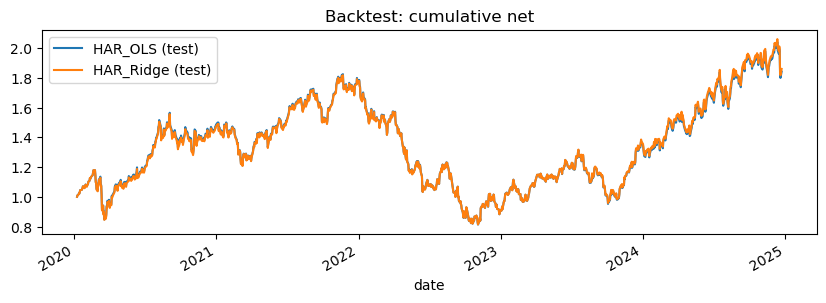

Final cum_net (OLS):  1.8418586416471623
Final cum_net (Ridge): 1.8602778618173799
Avg daily turnover (OLS):  0.04040087393039313
Avg daily turnover (Ridge): 0.042084972654141704


In [22]:
bt_ols = backtest(har_ols_pred[har_ols_pred["split"]=="test"], rets, target_vol=0.10, cost_bps=10, no_trade_pp=5)
bt_rdg = backtest(har_ridge_pred[har_ridge_pred["split"]=="test"], rets, target_vol=0.10, cost_bps=10, no_trade_pp=5)

ax = bt_ols.plot(x="date", y="cum_net", label="HAR_OLS (test)")
bt_rdg.plot(x="date", y="cum_net", ax=ax, label="HAR_Ridge (test)")
ax.set_title("Backtest: cumulative net")
plt.show()

print("Final cum_net (OLS): ", bt_ols["cum_net"].iloc[-1])
print("Final cum_net (Ridge):", bt_rdg["cum_net"].iloc[-1])
print("Avg daily turnover (OLS): ", bt_ols["turnover"].mean())
print("Avg daily turnover (Ridge):", bt_rdg["turnover"].mean())


### Export reports
Finally I persist both the daily backtest traces and a bite-sized summary table covering RMSEs, final net value, and average turnover. That way future experiments (or automation) can diff results without rerunning the notebook.

In [23]:
RES_DIR.mkdir(parents=True, exist_ok=True)
bt_ols.to_csv(RES_DIR/"har_h1_bt.csv", index=False)
bt_rdg.to_csv(RES_DIR/"har_ridge_h1_bt.csv", index=False)

report = pd.DataFrame({
    "model": ["HAR_OLS","HAR_Ridge_a0.5"],
    "val_rmse_logrv": [
        root_mean_squared_error(
            har_ols_pred.loc[har_ols_pred["split"]=="val","y_true_logrv"],
            har_ols_pred.loc[har_ols_pred["split"]=="val","yhat_logrv"],
        ),
        root_mean_squared_error(
            har_ridge_pred.loc[har_ridge_pred["split"]=="val","y_true_logrv"],
            har_ridge_pred.loc[har_ridge_pred["split"]=="val","yhat_logrv"],
        ),
    ],
    "test_rmse_logrv": [
        root_mean_squared_error(
            har_ols_pred.loc[har_ols_pred["split"]=="test","y_true_logrv"],
            har_ols_pred.loc[har_ols_pred["split"]=="test","yhat_logrv"],
        ),
        root_mean_squared_error(
            har_ridge_pred.loc[har_ridge_pred["split"]=="test","y_true_logrv"],
            har_ridge_pred.loc[har_ridge_pred["split"]=="test","yhat_logrv"],
        ),
    ],
    "test_final_cum_net": [bt_ols["cum_net"].iloc[-1], bt_rdg["cum_net"].iloc[-1]],
    "test_avg_turnover":  [bt_ols["turnover"].mean(), bt_rdg["turnover"].mean()],
})
report.to_csv(RES_DIR/"har_summary.csv", index=False)
report

,model,val_rmse_logrv,test_rmse_logrv,test_final_cum_net,test_avg_turnover
0,HAR_OLS,0.417147,0.409237,1.841859,0.040401
1,HAR_Ridge_a0.5,0.421150,0.410049,1.860278,0.042085


## Next Experiments

- Rerun the HAR loop for horizons 5 and 22 (swap the `horizon` argument in `build_har_table` and update filenames).
- Drop in a few exogenous bits (VIX lags, calendar flags) to get a HARX baseline and compare with a Diebold–Mariano test.
- Keep the prediction schema stable so the backtest stays plug-and-play.
- Once HAR/HARX are solid, try a tiny MLP/GRU or a trimmed-down TFT built on the exact same splits.